In [26]:
# ============================================================
# 1. Physics Defined & Imports
# ============================================================
"""
Physics-Informed Neural Network: Damped Harmonic Oscillator
Governing Equation: m·d²x/dt² + c·dx/dt + k·x = 0
Initial Conditions: x(0) = 1.0 (initial displacement)
                         dx/dt(0) = 0.0 (initial velocity)
Physical System: Spring-Mass-Damper
  - m = 1.0 kg (mass)
  - c = 0.5 N·s/m (damping coefficient)
  - k = 4.0 N/m (spring stiffness)
 
Exact Solution: x(t) = e^(-ζωₙt)[cos(ωₐt) + (ζωₙ/ωₐ)sin(ωₐt)]
  where: ωₙ = √(k/m) = 2.0 rad/s (natural frequency)
         ζ = c/(2√(mk)) = 0.125 (damping ratio)
         ωₐ = ωₙ√(1-ζ²) ≈ 1.992 rad/s (damped frequency)
"""
import deepxde as dde
from deepxde import utils
import numpy as np
import matplotlib.pyplot as plt
SEED = 42
dde.config.set_random_seed(SEED)
import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [27]:
# ============================================================
# 2. SETUP
# ============================================================
dde.config.set_default_float("float64")
print(f"Backend: {dde.backend.backend_name}")
# Physical parameters
m = 1.0 # mass (kg)
c = 0.5 # damping coefficient (N·s/m)
k = 4.0 # spring stiffness (N/m)
# Initial conditions
x0 = 1.0 # initial displacement (m)
v0 = 0.0 # initial velocity (m/s)
# Derived parameters
omega_n = np.sqrt(k/m) # Natural frequency
zeta = c / (2 * np.sqrt(m*k)) # Damping ratio
omega_d = omega_n * np.sqrt(1 - zeta**2) # Damped frequency
print("\n" + "="*60)
print("📊 SYSTEM PARAMETERS")
print("="*60)
print(f"Mass (m): {m} kg")
print(f"Damping (c): {c} N·s/m")
print(f"Stiffness (k): {k} N/m")
print(f"Natural Frequency (ωₙ): {omega_n:.4f} rad/s")
print(f"Damping Ratio (ζ): {zeta:.4f} (underdamped)")
print(f"Damped Frequency (ωₐ): {omega_d:.4f} rad/s")
print("="*60)
# Exact solution for validation
def exact_solution(t):
    """
    Analytical solution for underdamped harmonic oscillator
    x(t) = e^(-ζωₙt)[cos(ωₐt) + (ζωₙ/ωₐ)sin(ωₐt)]
    """
    exp_term = np.exp(-zeta * omega_n * t)
    cos_term = np.cos(omega_d * t)
    sin_term = (zeta * omega_n / omega_d) * np.sin(omega_d * t)
    return exp_term * (cos_term + sin_term)

# Exact velocity (derivative of displacement)
def exact_vx(t):
    """
    Analytical velocity: dx/dt
    """
    exp_term = np.exp(-zeta * omega_n * t)
    decay_rate = -zeta * omega_n
   
    x = exact_solution(t)
    dx_dt = decay_rate * x + exp_term * omega_d * (
        -np.sin(omega_d * t) + (zeta * omega_n / omega_d) * np.cos(omega_d * t)
    )
    return dx_dt

Set the default float type to float64
Backend: pytorch

📊 SYSTEM PARAMETERS
Mass (m): 1.0 kg
Damping (c): 0.5 N·s/m
Stiffness (k): 4.0 N/m
Natural Frequency (ωₙ): 2.0000 rad/s
Damping Ratio (ζ): 0.1250 (underdamped)
Damped Frequency (ωₐ): 1.9843 rad/s


In [28]:
# ============================================================
# 3. DEFINE PROBLEM
# ============================================================
# Time domain: 0 to 10 seconds
geom = dde.geometry.TimeDomain(0, 10)
# ODE: m·d²x/dt² + c·dx/dt + k·x = 0
# Rearranged: d²x/dt² = -(c/m)·dx/dt - (k/m)·x
def ode(t, x):
    """
    Harmonic oscillator ODE
    Input: t (time), x (displacement)
    Returns: residual of m·x'' + c·x' + k·x = 0
    """
    dx_dt = dde.grad.jacobian(x, t, i=0, j=0) # First derivative
    d2x_dt2 = dde.grad.hessian(x, t, i=0, j=0) # Second derivative
   
    # ODE residual: m·x'' + c·x' + k·x = 0
    residual = m * d2x_dt2 + c * dx_dt + k * x
    return residual

# Initial condition 1: x(0) = 1.0 (Displacement IC)
ic_displacement = dde.icbc.IC(geom, lambda t: x0, lambda _, on_initial: on_initial)



# Initial condition 2: dx/dt(0) = 0.0 (Velocity IC)
def velocity_ic(inputs, outputs, X):
    """
    Compute velocity residual: dx/dt - v0
    Args:
        inputs: time points (t)
        outputs: network predictions (x)
        X: spatial coordinates (not used for 1D time problem)
    """
    dx_dt = dde.grad.jacobian(outputs, inputs, i=0, j=0)
    return dx_dt - v0

def velocity_ic_location(t, on_initial):
    """Apply velocity IC ONLY at t=0 (not at t=10)"""
    return on_initial and np.isclose(t[0], 0.0)

ic_velocity = dde.icbc.OperatorBC(
    geom,
    velocity_ic,
    velocity_ic_location
)

In [ ]:
# ============================================================
# 4. GENERATE DATA
# ============================================================

# Training data: 35 measurements
observe_t = np.linspace(0, 10, 35).reshape(-1, 1)
observe_x = exact_solution(observe_t)

# Add 3% noise
noise = 0.03 * np.random.randn(35, 1)
observe_x = observe_x + noise

observe = dde.icbc.PointSetBC(observe_t, observe_x, component=0)

# Combine all constraints
data = dde.data.TimePDE(
    geom,
    ode,
    [ic_displacement, ic_velocity, observe],
    num_domain=3000,
    num_boundary=200,
    num_test=500,
    anchors=observe_t

)

print(f"\n✅ Problem defined successfully!")
print(f"   - ODE: m·x'' + c·x' + k·x = 0")
print(f"   - IC1: x(0) = {x0}")
print(f"   - IC2: dx/dt(0) = {v0}")
print(f"   - Training points: {len(observe_t)}")


✅ Problem defined successfully!
   - ODE: m·x'' + c·x' + k·x = 0
   - IC1: x(0) = 1.0
   - IC2: dx/dt(0) = 0.0
   - Training points: 35


In [30]:
# 5. BUILD NEURAL NETWORK
# ============================================================
# Architecture: 1 input (time) → 3 hidden layers → 1 output (displacement)
net = dde.nn.FNN([1, 256, 128, 64, 1], "tanh", "Glorot uniform")

In [31]:
# 6. CREATE MODEL
# ============================================================
model = dde.Model(data, net)

In [32]:
# ============================================================
# 7. SELF-ADAPTIVE SOFTMAX CALLBACK
# ============================================================

class SoftmaxAdaptiveWeights(dde.callbacks.Callback):
    def __init__(self, model, every_n_epochs=100, alpha_0=1.0, gamma=0.999):  # FIXED: Add model param
        super().__init__()
        self.model = model  # Store reference
        self.every_n_epochs = every_n_epochs
        self.alpha = alpha_0
        self.gamma = gamma
        self.epoch = 0  # Or use self.step = 0 for L-BFGS steps

    def on_epoch_end(self):
        self.epoch += 1  # For Adam; consider self.step += 1 for general
        if self.epoch % self.every_n_epochs != 0:
            return
        
        if len(self.model.losshistory.loss_train) == 0:  # FIXED: Use self.model
            return
        
        current_losses = self.model.losshistory.loss_train[-1]
        exp_terms = np.exp(self.alpha * np.array(current_losses))
        new_weights = exp_terms / np.sum(exp_terms)
        self.alpha *= self.gamma
        self.model.loss_weights = new_weights.tolist()  # FIXED: Use self.model
        
        print(f"Epoch {self.epoch}: Adaptive weights updated to {new_weights.tolist()}, alpha decayed to {self.alpha:.4f}")

# After model creation (Section 5):
adaptive_callback = SoftmaxAdaptiveWeights(model, every_n_epochs=50)  # FIXED: Pass model

In [ ]:
# ============================================================
# 8. TRAIN MODEL (Two-Stage with Adaptive Callback)
# ============================================================
print("\nStage 1: Adam Optimizer")
model.compile(
    "adam",
    lr=0.001, 
    loss_weights=[1.0] * 4,  # Initial uniform; callback adapts
    decay=("inverse time", 10000, 0.1)
)
losshistory, train_state = model.train(iterations=20000, display_every=2000, callbacks=[adaptive_callback])

print("\nStage 2: L-BFGS Optimizer (Fine-tuning)")
model.compile("L-BFGS", loss_weights=model.loss_weights)  # Carry over adapted weights
losshistory, train_state = model.train(display_every=500, callbacks=[adaptive_callback])


Stage 1: Adam Optimizer
Compiling model...
'compile' took 0.000550 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [4.42e+00, 1.00e+00, 1.70e-02, 3.83e-01]    [4.43e+00, 1.00e+00, 1.70e-02, 3.83e-01]    []  
Epoch 50: Adaptive weights updated to [0.9409275663514151, 0.03087103824454539, 0.011551973964879869, 0.0166494214391597], alpha decayed to 0.9990
Epoch 100: Adaptive weights updated to [0.9407169241680126, 0.030969771840785806, 0.011600317247521728, 0.0167129867436798], alpha decayed to 0.9980
Epoch 150: Adaptive weights updated to [0.9405057809941492, 0.03106869694176335, 0.011648804795406031, 0.01677671726868164], alpha decayed to 0.9970
Epoch 200: Adaptive weights updated to [0.9402941366592659, 0.03116781345551847, 0.011697436772207062, 0.016840613113008704], alpha decayed to 0.9960
Epoch 250: Adaptive weights updated to [0.940081990996771, 0.03126712128833121, 0.011746213340663173, 

In [34]:
# 9. EVALUATE RESULTS
# ============================================================
test_points = 15
t_test = np.linspace(0, 10, test_points).reshape(-1, 1)
x_pred = model.predict(t_test)
x_exact = exact_solution(t_test)
noise = 0.03 * np.random.randn(15, 1)   # 3% noise
x_test = x_exact + noise

# Calculate errors
absolute_error = np.abs(x_test - x_pred)
relative_error = absolute_error / (np.abs(x_test) + 1e-10)
l2_error = np.linalg.norm(x_test - x_pred) / np.linalg.norm(x_test)
# Check initial conditions
x_at_0 = model.predict(np.array([[0.0]]))[0, 0]
# Velocity at t=0
t_zero = np.array([[0.0]])
v_at_0 = model.predict(
    t_zero,
    operator=lambda t, x: dde.grad.jacobian(x, t, i=0, j=0)
)[0, 0]
print("\n" + "="*60)
print("📊 PERFORMANCE METRICS")
print("="*60)
print(f"L2 Relative Error: {l2_error:.6f}")
print(f"Mean Absolute Error: {np.mean(absolute_error):.6f}")
print(f"Mean Absolute Relative Error: {np.mean(relative_error):.6f}")
print("\n📍 INITIAL CONDITION CHECK")
print("-"*60)
print(f"x(0) = {x_at_0:.6f} (Target: {x0})")
print(f"dx/dt(0) = {v_at_0:.6f} (Target: {v0})")
print("="*60)


📊 PERFORMANCE METRICS
L2 Relative Error: 0.100442
Mean Absolute Error: 0.028546
Mean Absolute Relative Error: 0.293760

📍 INITIAL CONDITION CHECK
------------------------------------------------------------
x(0) = 0.999960 (Target: 1.0)
dx/dt(0) = -0.000022 (Target: 0.0)


In [35]:
# 10. EXTRACT TRUE INDIVIDUAL LOSSES
# ==================================
final_train_losses = model.losshistory.loss_train[-1]
L_ode, L_ic_x, L_ic_v, L_data = final_train_losses
print("\n" + "="*60)
print("📉 FINAL TRAINING LOSSES (Unweighted)")
print("="*60)
print(f"L_ODE : {L_ode:.6e}")
print(f"L_IC_x : {L_ic_x:.6e}")
print(f"L_IC_v : {L_ic_v:.6e}")
print(f"L_data : {L_data:.6e}")
print("\n📉 WEIGHTED CONTRIBUTIONS")
print("="*60)
# FIXED: Use model.loss_weights instead of undefined loss_weights
current_weights = model.loss_weights  # Dynamic access to final adapted weights
weighted = [w * l for w, l in zip(current_weights, final_train_losses)]
print(f"λ_ODE × L_ODE : {weighted[0]:.6e}")
print(f"λ_IC_x × L_IC_x : {weighted[1]:.6e}")
print(f"λ_IC_v × L_IC_v : {weighted[2]:.6e}")
print(f"λ_data × L_data : {weighted[3]:.6e}")
print(f"\nTotal Weighted : {sum(weighted):.6e}")
print("="*60)
# %%


📉 FINAL TRAINING LOSSES (Unweighted)
L_ODE : 7.344082e-06
L_IC_x : 3.902888e-10
L_IC_v : 1.261128e-10
L_data : 1.771567e-04

📉 WEIGHTED CONTRIBUTIONS
λ_ODE × L_ODE : 1.836052e-06
λ_IC_x × L_IC_x : 9.756785e-11
λ_IC_v × L_IC_v : 3.152652e-11
λ_data × L_data : 4.429277e-05

Total Weighted : 4.612896e-05



💾 Results saved to 'pinn_harmonic_oscillator_results.png'


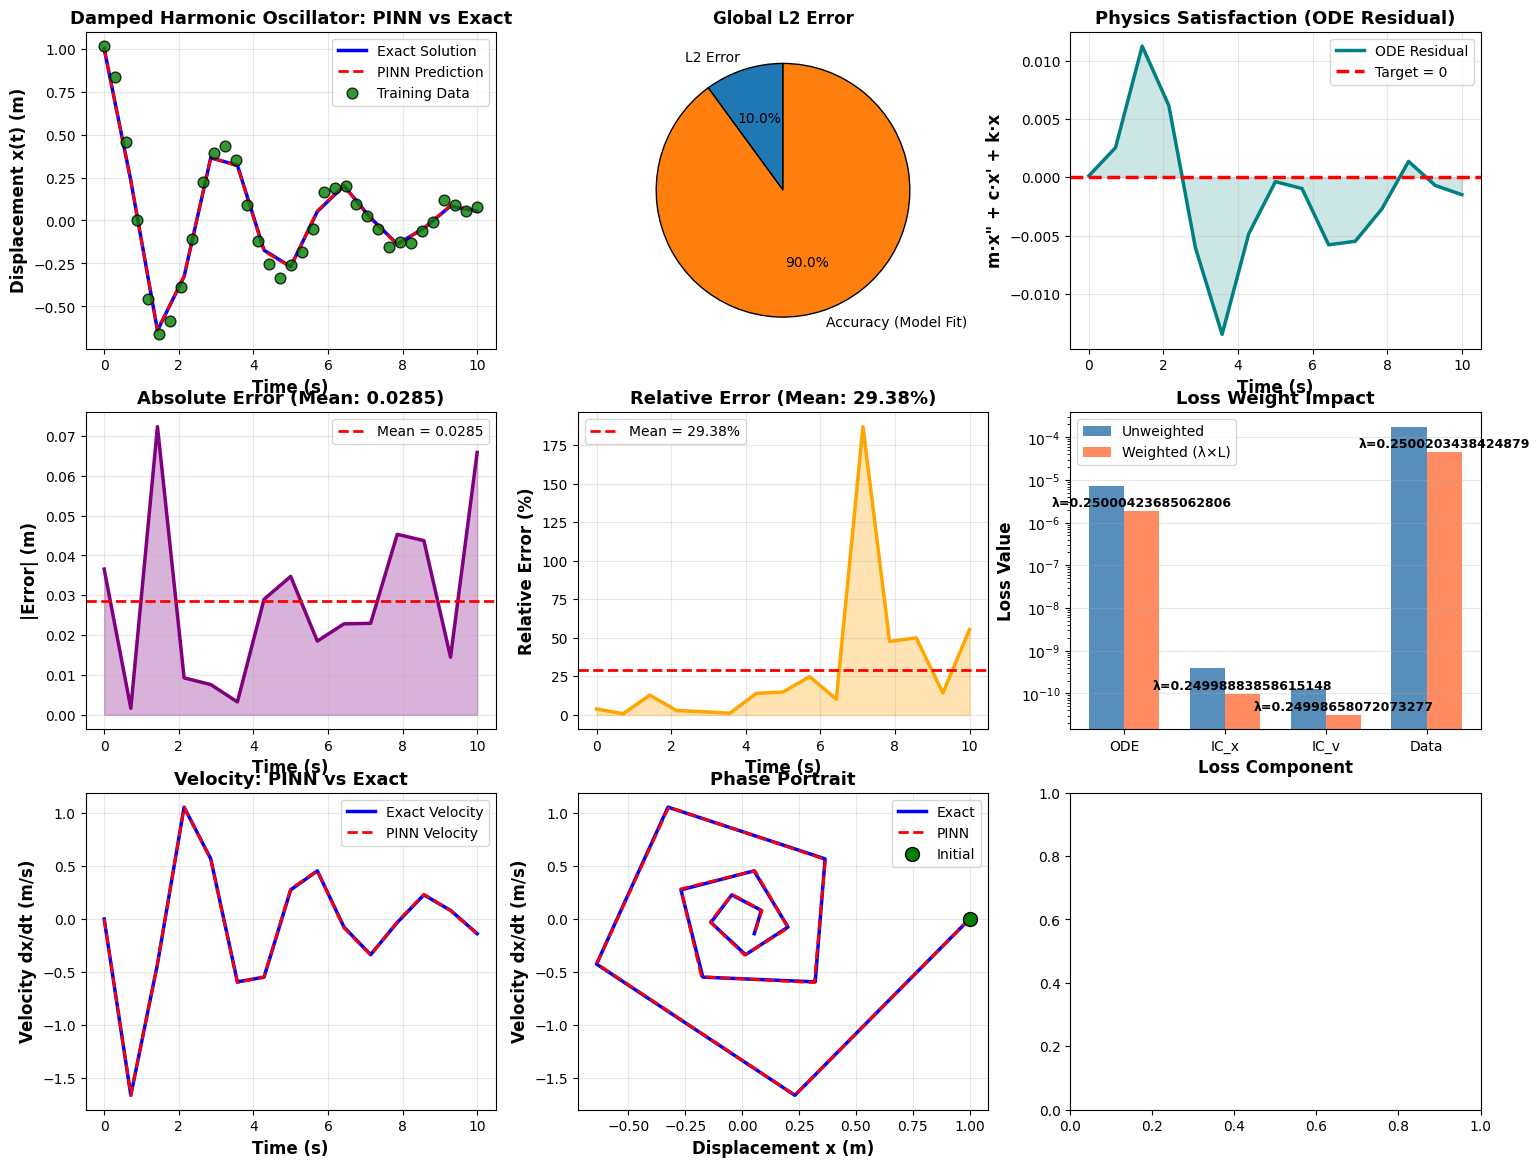

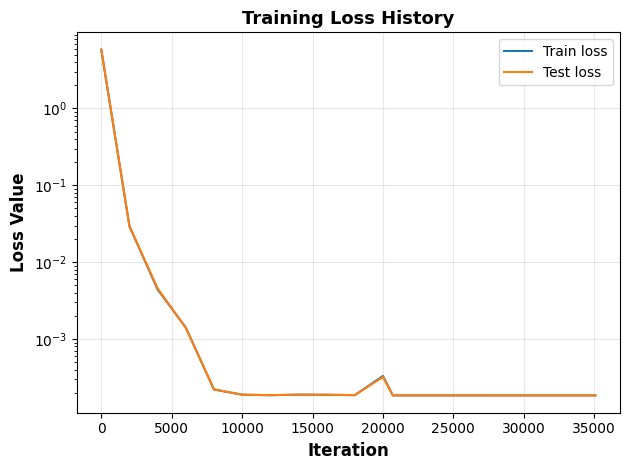

In [ ]:
# 11. VISUALIZATION
# ============================================================
fig = plt.figure(figsize=(18, 14))

# ------------------------------------------------------------
# Plot 1: Solution Comparison
# ------------------------------------------------------------
ax1 = plt.subplot(3, 3, 1)
plt.plot(t_test, x_exact, 'b-', linewidth=2.5, label='Exact Solution')
plt.plot(t_test, x_pred, 'r--', linewidth=2, label='PINN Prediction')
plt.scatter(
    t_test, x_test, c='green', s=60,
    label='Test Data', zorder=5, alpha=0.8, edgecolors='black'
)
plt.xlabel('Time (s)', fontsize=12, fontweight='bold')
plt.ylabel('Displacement x(t) (m)', fontsize=12, fontweight='bold')
plt.title('Damped Harmonic Oscillator: PINN vs Exact', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Plot 2: Global L2 Error Pie Chart
# ------------------------------------------------------------
ax2 = plt.subplot(3, 3, 2)
l2_error_pct = 100 * np.linalg.norm(x_test - x_pred) / np.linalg.norm(x_test)
sizes = [l2_error_pct, 100 - l2_error_pct]
labels = ['L2 Error', 'Accuracy (Model Fit)']

ax2.pie(
    sizes, labels=labels, autopct='%1.1f%%', startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'}
)
ax2.set_title('Global L2 Error', fontsize=12, fontweight='bold')
ax2.set_aspect('equal')

# ------------------------------------------------------------
# Plot 3: Physics Check (ODE Residual)
# ------------------------------------------------------------
ax3 = plt.subplot(3, 3, 3)
ode_residual = model.predict(
    t_test,
    operator=lambda t, x: m * dde.grad.hessian(x, t, i=0, j=0)
                        + c * dde.grad.jacobian(x, t, i=0, j=0)
                        + k * x
)

plt.plot(t_test, ode_residual, 'teal', linewidth=2.5, label='ODE Residual')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2.5, label='Target = 0')
plt.fill_between(t_test.flatten(), 0, ode_residual.flatten(), alpha=0.2, color='teal')
plt.xlabel('Time (s)', fontsize=12, fontweight='bold')
plt.ylabel('m·x" + c·x\' + k·x', fontsize=12, fontweight='bold')
plt.title('Physics Satisfaction (ODE Residual)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Plot 4: Absolute Error
# ------------------------------------------------------------
ax4 = plt.subplot(3, 3, 4)
plt.plot(t_test, absolute_error, color='purple', linewidth=2.5)
mean_abs_err = np.mean(absolute_error)

plt.axhline(
    y=mean_abs_err, color='red', linestyle='--', linewidth=2,
    label=f'Mean = {mean_abs_err:.4f}'
)
plt.fill_between(t_test.flatten(), 0, absolute_error.flatten(), alpha=0.3, color='purple')

plt.xlabel('Time (s)', fontsize=12, fontweight='bold')
plt.ylabel('|Error| (m)', fontsize=12, fontweight='bold')
plt.title(f'Absolute Error (Mean: {mean_abs_err:.4f})', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Plot 5: Relative Error
# ------------------------------------------------------------
ax5 = plt.subplot(3, 3, 5)
plt.plot(t_test, relative_error * 100, color='orange', linewidth=2.5)

mean_rel_err_pct = np.mean(relative_error) * 100
plt.axhline(
    y=mean_rel_err_pct, color='red', linestyle='--', linewidth=2,
    label=f'Mean = {mean_rel_err_pct:.2f}%'
)
plt.fill_between(
    t_test.flatten(), 0, (relative_error * 100).flatten(),
    alpha=0.3, color='orange'
)

plt.xlabel('Time (s)', fontsize=12, fontweight='bold')
plt.ylabel('Relative Error (%)', fontsize=12, fontweight='bold')
plt.title(f'Relative Error (Mean: {mean_rel_err_pct:.2f}%)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Plot 6: Loss Weight Analysis
# ------------------------------------------------------------
ax6 = plt.subplot(3, 3, 6)
losses = model.losshistory.loss_train[-1]
# FIXED: Access dynamic weights from model attribute
current_weights = model.loss_weights
weighted = [w * l for w, l in zip(current_weights, losses)]
components = ['ODE', 'IC_x', 'IC_v', 'Data']

x_pos = np.arange(len(components))
width = 0.35

ax6.bar(x_pos - width/2, losses, width, label='Unweighted', alpha=0.9, color='steelblue')
ax6.bar(x_pos + width/2, weighted, width, label='Weighted (λ×L)', alpha=0.9, color='coral')

ax6.set_xlabel('Loss Component', fontsize=12, fontweight='bold')
ax6.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
ax6.set_title('Loss Weight Impact', fontsize=13, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(components)
ax6.set_yscale('log')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')

for bar, λ in zip(ax6.patches[len(components):], current_weights):
    h = bar.get_height()
    ax6.text(
        bar.get_x() + bar.get_width()/2, h * 1.1,
        f'λ={λ}', ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )



# ------------------------------------------------------------
# Plot 7: Velocity Comparison
# ------------------------------------------------------------
ax7 = plt.subplot(3, 3, 7)
v_pred = model.predict(t_test, operator=lambda t, x: dde.grad.jacobian(x, t, i=0, j=0))
v_exact = exact_vx(t_test)

plt.plot(t_test, v_exact, 'b-', linewidth=2.5, label='Exact Velocity')
plt.plot(t_test, v_pred, 'r--', linewidth=2, label='PINN Velocity')

plt.xlabel('Time (s)', fontsize=12, fontweight='bold')
plt.ylabel('Velocity dx/dt (m/s)', fontsize=12, fontweight='bold')
plt.title('Velocity: PINN vs Exact', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Plot 8: Phase Portrait
# ------------------------------------------------------------
ax8 = plt.subplot(3, 3, 8)
plt.plot(x_exact, v_exact, 'b-', linewidth=2.5, label='Exact')
plt.plot(x_pred, v_pred, 'r--', linewidth=2, label='PINN')

plt.scatter(
    [x0], [v0], c='green', s=100, marker='o',
    label='Initial', zorder=5, edgecolors='black'
)
plt.xlabel('Displacement x (m)', fontsize=12, fontweight='bold')
plt.ylabel('Velocity dx/dt (m/s)', fontsize=12, fontweight='bold')
plt.title('Phase Portrait', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)


# ------------------------------------------------------------
# Plot 9: Loss History
# ------------------------------------------------------------
ax9 = plt.subplot(3, 3, 9)
dde.utils.plot_loss_history(losshistory)
plt.title('Training Loss History', fontsize=13, fontweight='bold')
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Loss Value', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)



# ------------------------------------------------------------
# Final Layout + Save
# ------------------------------------------------------------
plt.tight_layout()
plt.savefig('pinn_harmonic_oscillator_results.png', dpi=300, bbox_inches='tight')
print("\n💾 Results saved to 'pinn_harmonic_oscillator_results.png'")
plt.show()


In [37]:
# 12. FINAL SUMMARY
# ============================================================
def fmt(label, value, width_label=45, width_value=12):
    return f"{label:<{width_label}} : {value:>{width_value}}"
print("\n" + "=" * 70)
print("📋 FINAL SUMMARY".center(70))
print("=" * 70)
# System Information
print("\n" + "═" * 70)
print("PHYSICAL SYSTEM".center(70))
print("═" * 70)
print(fmt("Backend", dde.backend.backend_name))
print(fmt("Mass (m)", f"{m} kg"))
print(fmt("Damping (c)", f"{c} N·s/m"))
print(fmt("Stiffness (k)", f"{k} N/m"))
print(fmt("Natural Frequency (ωₙ)", f"{omega_n:.4f} rad/s"))
print(fmt("Damping Ratio (ζ)", f"{zeta:.4f}"))
print(fmt("System Type", "Underdamped"))
print("═" * 70)
# Training Points
print("\n" + "═" * 70)
print("TRAINING POINTS CONFIGURATION".center(70))
print("═" * 70)
print(fmt("Physics collocation points", data.num_domain))
print(fmt("Boundary (IC) points", data.num_boundary))
print(fmt("Total training points", data.train_x_all.shape[0]))
print("-" * 70)
print(fmt("Experimental data points", len(observe_t)))
print("-" * 70)
print(fmt("Test points", test_points))
print("═" * 70)
# Neural Network
print("\nNEURAL NETWORK ARCHITECTURE")
print("-" * 70)
print(net)
print("-" * 70)
# Best Model Performance
best_step = np.argmin([sum(l) for l in model.losshistory.loss_test])
best_train = model.losshistory.loss_train[best_step]
best_test = model.losshistory.loss_test[best_step]
print("\n" + "═" * 70)
print("BEST MODEL PERFORMANCE".center(70))
print("═" * 70)
print(fmt("Best iteration", best_step))
print("-" * 70)
print(fmt("Total weighted training loss", f"{sum(best_train):.6e}"))
print(fmt("Train → ODE loss", f"{best_train[0]:.6e}"))
print(fmt("Train → IC_x loss", f"{best_train[1]:.6e}"))
print(fmt("Train → IC_v loss", f"{best_train[2]:.6e}"))
print(fmt("Train → Data loss", f"{best_train[3]:.6e}"))
print("-" * 70)
print(fmt("Total weighted test loss", f"{sum(best_test):.6e}"))
print(fmt("Test → ODE loss", f"{best_test[0]:.6e}"))
print(fmt("Test → IC_x loss", f"{best_test[1]:.6e}"))
print(fmt("Test → IC_v loss", f"{best_test[2]:.6e}"))
print(fmt("Test → Data loss", f"{best_test[3]:.6e}"))
print("═" * 70)
# Final Losses
print("\n" + "═" * 70)
print("FINAL TRAINING LOSSES".center(70))
print("═" * 70)
print(f"{'Component':<15} {'Unweighted':>15} {'Weighted (λ×L)':>20} {'λ':>8}")
print("-" * 70)
components = ["ODE", "IC_x", "IC_v", "Data"]
for i, comp in enumerate(components):
    L = final_train_losses[i]
    w = current_weights[i]
    print(f"{comp:<15} {L:>15.6e} {w*L:>20.6e} {w:>8}")
print("-" * 70)
print(f"{'TOTAL WEIGHTED LOSS':<35}{sum(weighted):>20.6e}")
print("═" * 70)
# Metrics
print("\n📊 METRICS")
print("-" * 70)
print(f"{'Metric':<35} {'Value':>15} {'Target'}")
print("-" * 70)
print(f"{'L2 Relative Error':<35} {l2_error:>15.6f} < 0.05")
print(f"{'Mean Absolute Error':<35} {np.mean(absolute_error):>15.6f} < 0.10")
print(f"{'Mean Absolute Relative Error':<35} {np.mean(relative_error):>15.6f} < 0.20")
print("\n")
print(f"{'x(0) [should be {x0}]':<35} {x_at_0:>15.6f} {x0}")
print(f"{'dx/dt(0) [should be {v0}]':<35} {v_at_0:>15.6f} {v0}")
print(f"{'ODE Residual (mean abs)':<35} {np.mean(np.abs(ode_residual)):>15.6f} < 0.10")
print("=" * 70)


                           📋 FINAL SUMMARY                            

══════════════════════════════════════════════════════════════════════
                           PHYSICAL SYSTEM                            
══════════════════════════════════════════════════════════════════════
Backend                                       :      pytorch
Mass (m)                                      :       1.0 kg
Damping (c)                                   :    0.5 N·s/m
Stiffness (k)                                 :      4.0 N/m
Natural Frequency (ωₙ)                        : 2.0000 rad/s
Damping Ratio (ζ)                             :       0.1250
System Type                                   :  Underdamped
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
                    TRAINING POINTS CONFIGURATION                     
══════════════════════════════════════════════════════════════════════
Ph

In [38]:
# 13. SAVE MODEL
# ============================================================
model.save("pinn_harmonic_oscillator_model")
print("\n💾 Model saved to 'pinn_harmonic_oscillator_model/'")
config = {
    'loss_weights': model.loss_weights,
    'architecture': [1, 256, 128, 64, 1],
    'activation': 'tanh',
    'physical_parameters': {'m': m, 'c': c, 'k': k},
    'initial_conditions': {'x0': x0, 'v0': v0},
    'l2_error': float(l2_error),
    'training_iterations': 20000
}
import json
with open('pinn_harmonic_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print("💾 Configuration saved to 'pinn_harmonic_config.json'")
print("\n✅ PINN TRAINING COMPLETE FOR HARMONIC OSCILLATOR!")


💾 Model saved to 'pinn_harmonic_oscillator_model/'
💾 Configuration saved to 'pinn_harmonic_config.json'

✅ PINN TRAINING COMPLETE FOR HARMONIC OSCILLATOR!
